In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('online_retail.csv', encoding='latin1')
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)

(541909, 8)
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


Data Quality Report

The dataset has 541,909 rows and 8 columns. CustomerID has 135,080 missing values - about 25% of the data. Description has 1,454 missing values. Since this task is about segmenting customers, rows without a CustomerID are useless and will be removed.

In [30]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(df.shape)

(397884, 8)


Cleaning

Removed rows with no CustomerID since you can't segment a customer you can't identify. Also removed rows with negative or zero Quantity/UnitPrice, since those are returns or data errors, not real purchases. Row count went from 541,909 to 397,884.

In [31]:
# Create a "Total Price" column per line item
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Set a reference date (one day after the last invoice date in the data)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by customer to build RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                         # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
print(rfm.head())
print(rfm.describe())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


Feature Selection (RFM)

Built RFM features for each customer:
- Recency: days since their last purchase
- Frequency: number of separate orders placed
- Monetary: total amount spent

These three features capture the core of customer purchasing behavior and are standard for segmentation. There are 4,338 unique customers after cleaning.

Descriptive Statistics

On average, customers made about 4.3 orders and spent around $2,054 total (Monetary), though this varies a lot - some customers spent as little as $3.75 and one spent over $280,000. Average recency is about 93 days since last purchase.

In [32]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)
print(rfm_scaled.head())

             Recency  Frequency  Monetary
CustomerID                               
12346.0     2.334574  -0.425097  8.358668
12347.0    -0.905340   0.354417  0.250966
12348.0    -0.175360  -0.035340 -0.028596
12349.0    -0.735345  -0.425097 -0.033012
12350.0     2.174578  -0.425097 -0.191347


Normalisation

Scaled Recency, Frequency, and Monetary using StandardScaler before clustering. This is needed because these features are on very different scales (days vs order count vs dollars) - without scaling, Monetary would dominate the clustering since it has the largest numbers.

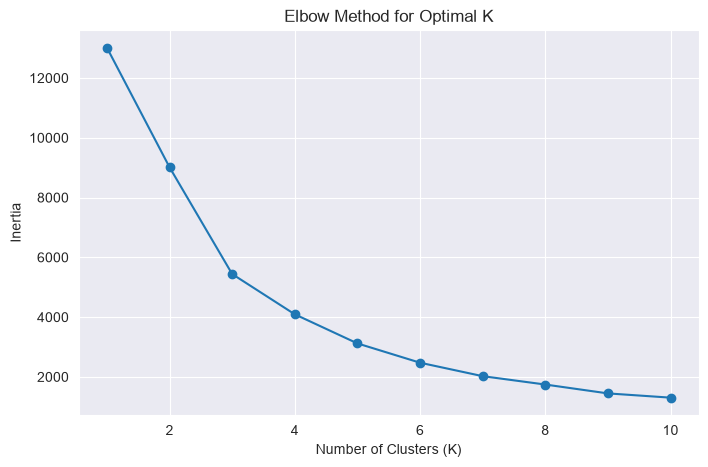

In [33]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

Elbow Method

Used the Elbow Method to find the optimal number of clusters. The curve bends sharply around K=4, after which adding more clusters gives diminishing returns. So K=4 was chosen for the final clustering.

In [34]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
print(rfm.head())
print(rfm['Cluster'].value_counts())

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        3
12347.0           2          7   4310.00        0
12348.0          75          4   1797.24        0
12349.0          19          1   1757.55        0
12350.0         310          1    334.40        1
Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64


K-Means Clustering

Applied K-Means with K=4 clusters. Cluster sizes: Cluster 0 has 3,054 customers (the majority), Cluster 1 has 1,067, Cluster 3 has 204, and Cluster 2 has only 13 - likely very high-value outlier customers.

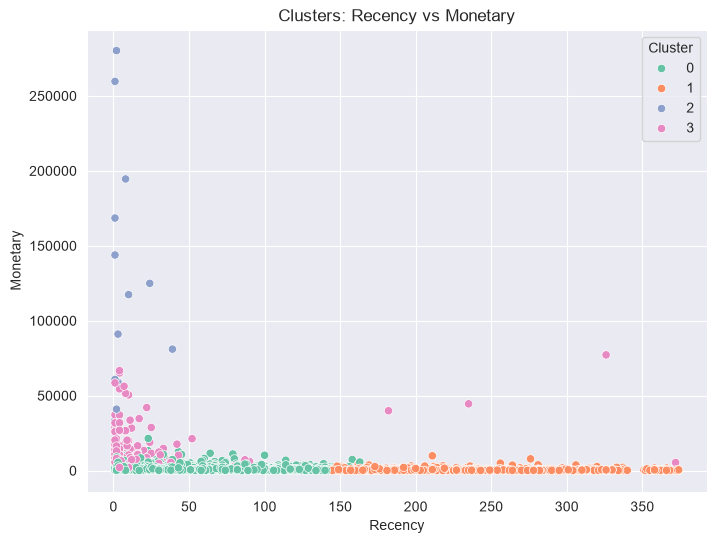

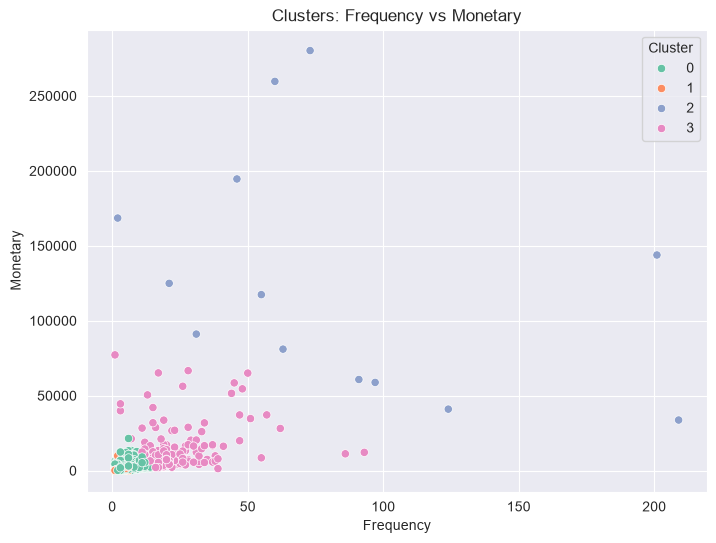

In [35]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2')
plt.title('Clusters: Recency vs Monetary')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2')
plt.title('Clusters: Frequency vs Monetary')
plt.show()

Cluster Visualisation

Cluster 2 (grey) is clearly separated - very high spenders regardless of frequency, includes one customer with 200+ orders. Cluster 3 (pink) sits in the mid-high spending range with low recency (recent buyers). Clusters 0 and 1 (green/orange) overlap more, both being low-to-moderate spenders, mainly differentiated by recency - Cluster 0 buys more recently, Cluster 1 hasn't purchased in a while.

         Recency  Frequency  Monetary
Cluster                              
0           43.7        3.7    1359.0
1          248.1        1.6     480.6
2            7.4       82.5  127338.3
3           15.5       22.3   12709.1


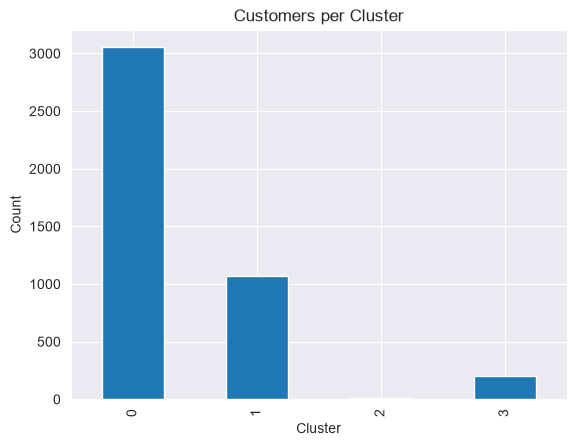

In [36]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)
print(cluster_profile)

rfm['Cluster'].value_counts().sort_index().plot(kind='bar', title='Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

Cluster Profiling

Cluster 0 (3,054 customers): buy moderately often, spent recently, average spend - these are regular, active customers.

Cluster 1 (1,067 customers): haven't purchased in ~8 months on average and spend the least - these are lapsed or at-risk customers.

Cluster 2 (only 13 customers): buy very frequently (82+ orders) and spend massively (~$127k average) - these are VIP customers, the most valuable segment by far despite being a tiny group.

Cluster 3 (204 customers): buy fairly often and spend a good amount (~$12.7k average), and bought recently - loyal, high-value customers just below VIP tier.

Marketing Recommendations

Cluster 0 (Regular): Keep engaged with regular email campaigns and seasonal offers to maintain purchase frequency.

Cluster 1 (At-risk): Send win-back campaigns with discounts or reminders - they haven't bought in a while and may be close to churning entirely.

Cluster 2 (VIP): Treat as top priority - dedicated account support, early access to new products, loyalty rewards. Losing even one of these 13 customers is a major revenue hit.

Cluster 3 (Loyal high-value): Upsell and cross-sell opportunities, loyalty program tiers to push them toward VIP status.